
# Triadic Cell Notebook v41
## Interface–Surface–Completion runtime

This notebook codes the next step in the line.

The missing operator is **completion**:
not just a better seat, and not just a better selector,
but a **signed completion field** that writes back into shared matter.

The architecture is:

- **Interface** = inverse vacuum, the unresolved cavity
- **Surface** = declared observable, request mask, local signed correction
- **Completion** = branch-specific fit advantage on the same requested slice, with **counter-flux** against rivals

This is the intended shift:

$$
\text{do not only add winner flux}
$$

$$
\text{also remove incompatible matter on the same slice}
$$

So v41 keeps:
- fixed live branches
- resoluteness-breath
- gap masks

and adds:
- completion-as-counterflux
- rival-specific anti-flux on the same slice
- completion memory across cycles
- shared matter update driven by interface + surface + completion



## Practical meaning

This is still runtime control, not base-model training.

v41 implements the law:

1. declare the cavity
2. let branches surface local fits
3. let completion push positively for self-fit
4. let completion push negatively against rival-fit on the same slice
5. update one shared matter field

Main outputs:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `completion_summary`
- `completion_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)
print("Environment ready.")


Environment ready.


## Canonical triadic chain

In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [[0.95,0.15,0.10,0.20,0.30,0.10],[0.70,0.25,0.45,0.30,0.45,0.20],[0.55,0.20,0.60,0.25,0.70,0.35]],
    [[0.10,0.95,0.15,0.25,0.10,0.30],[0.25,0.72,0.25,0.50,0.25,0.45],[0.20,0.58,0.30,0.70,0.30,0.72]],
    [[0.20,0.10,0.95,0.15,0.25,0.12],[0.45,0.25,0.75,0.30,0.42,0.22],[0.62,0.22,0.55,0.25,0.72,0.30]],
    [[0.15,0.22,0.18,0.95,0.12,0.35],[0.28,0.42,0.25,0.75,0.22,0.58],[0.35,0.72,0.30,0.60,0.25,0.78]],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a, b):
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape, local_mold, alpha=0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936


## Directional basis

In [3]:

raw_basis = np.array([
    [1.0,0.0,0.6,0.2,0.0,0.3],
    [0.2,1.0,0.0,0.6,0.2,0.0],
    [0.0,0.2,1.0,0.0,0.6,0.2],
    [0.6,0.0,0.2,1.0,0.0,0.6],
    [0.0,0.6,0.2,0.0,1.0,0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)

## Query corruption

In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls, mode):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.015, size=q.shape[0])
    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.45
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])
    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])
    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.56 * target + 0.44 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])
    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)


## Core fold decomposition

In [5]:

def directional_coeffs(x):
    return U @ x

def reconstruct_from_coeffs(c):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query, target):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    return {
        "R": R, "M": M, "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
    }


## Candidate evaluation

In [6]:

def triadic_evaluate(query, cls):
    s0, _, _ = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.45 * (1.0 - retrieve_fit)
    )

    declaration_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.95 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.45 * bridge_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "declared_value": projected2,
    }

def triadic_query(query):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def produce_fields_for_class(query, cls):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    retrieve_mask = normalize01(ev["R"])
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "declaration_score": ev["declaration_score"],
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"])


## Observables, vacuum, and gap masks

In [7]:

obs_dim = 3

OBS_W = np.array([
    [0.80,0.10,0.35,0.05,0.20,0.10],
    [0.10,0.75,0.10,0.30,0.05,0.25],
    [0.20,0.10,0.55,0.10,0.45,0.20],
], dtype=float)

def observable_from_declared(declared_value):
    return normalize01(OBS_W @ declared_value)

def build_inverse_vacuum(query, fields):
    inv_query = 1.0 - query
    contradiction = fields["contradiction_mask"]
    return normalize01(0.75 * inv_query + 0.25 * contradiction)

def apply_resoluteness(x, rho, eps=1e-8):
    return normalize01(np.clip(x, eps, 1.0) ** rho)

def build_gap_masks(pred_obs_by_cls):
    gap_masks = {}
    classes = list(pred_obs_by_cls.keys())
    for cls in classes:
        others = [pred_obs_by_cls[c] for c in classes if c != cls]
        if others:
            other_mean = np.mean(np.stack(others, axis=0), axis=0)
        else:
            other_mean = np.zeros_like(pred_obs_by_cls[cls])
        gap_masks[cls] = normalize01(np.abs(pred_obs_by_cls[cls] - other_mean))
    return gap_masks

def build_request_shape_gap(shared_matter, fields, gap_mask, rho=1.0, top_k=1):
    pred_obs = observable_from_declared(fields["declared_value"])
    vacuum = build_inverse_vacuum(shared_matter, fields)
    vacuum_obs = normalize01(OBS_W @ vacuum)

    vacuum_obs_r = apply_resoluteness(vacuum_obs, rho)
    need_obs_r = apply_resoluteness(1.0 - pred_obs, rho)
    gap_obs_r = apply_resoluteness(gap_mask, rho)

    request_scores = vacuum_obs_r * need_obs_r * (0.5 + 0.5 * gap_obs_r)
    idx = np.argsort(request_scores)[-top_k:]

    mask = np.zeros(obs_dim, dtype=float)
    mask[idx] = 1.0

    tol_lo, tol_hi = 0.08, 0.30
    t = min(max((rho - 0.35) / 1.10, 0.0), 1.0)
    tolerance = tol_hi * (1.0 - t) + tol_lo * t

    return {
        "mask": mask,
        "expected_profile": pred_obs,
        "vacuum_obs": vacuum_obs_r,
        "gap_obs": gap_obs_r,
        "tolerance": float(tolerance),
        "priority": float((vacuum_obs_r * (0.5 + 0.5 * gap_obs_r)).mean()),
        "rho": float(rho),
    }

def provider_pull(true_cls, request_shape):
    full_obs = observable_from_declared(chains[true_cls][2])
    mask = request_shape["mask"]
    packet = full_obs * mask + rng.normal(0.0, 0.02, size=full_obs.shape[0]) * mask
    return normalize01(packet)

def masked_error(obs_packet, pred_obs, mask):
    return float(np.mean(np.abs(mask * (obs_packet - pred_obs))))

def softmax_stable(x):
    x = np.array(x, dtype=float)
    z = x - np.max(x)
    e = np.exp(z)
    return e / (np.sum(e) + 1e-8)

def branch_entropy_from_scores(scores):
    p = softmax_stable(scores)
    return float(-np.sum(p * np.log(p + 1e-8)))


## Priors and control

In [8]:

DIRECT_THRESHOLD = 0.985
SHAPE_THRESHOLD = 0.78

def direct_lookup_score(query):
    scores = [(cls, cosine_similarity(query, chains[cls][0])) for cls in range(n_classes)]
    scores.sort(key=lambda x: x[1], reverse=True)
    cls, score = scores[0]
    return {"class": cls, "score": float(score), "hit": score >= DIRECT_THRESHOLD}

def shape_lookup_score(query):
    best, _, margin = triadic_query(query)
    return {"class": best["class"], "score": float(best["retrieve_fit"]), "margin": float(margin), "hit": best["retrieve_fit"] >= SHAPE_THRESHOLD}

def seat_gain(before_fields, after_fields):
    before_missing = float(before_fields["missing_mask"].mean())
    after_missing = float(after_fields["missing_mask"].mean())
    before_contra = float(before_fields["contradiction_mask"].mean())
    after_contra = float(after_fields["contradiction_mask"].mean())
    before_decl = float(before_fields["declaration_score"])
    after_decl = float(after_fields["declaration_score"])
    return float(
        0.60 * (before_missing - after_missing)
        - 0.25 * (after_contra - before_contra)
        + 0.15 * (after_decl - before_decl)
    )

def rho_from_field(mean_seat_gain, mean_obs_misfit, winner_margin, entropy):
    raw = 4.0 * mean_seat_gain - 3.0 * mean_obs_misfit + 2.0 * winner_margin - 1.5 * entropy
    sig = 1.0 / (1.0 + np.exp(-raw))
    return float(0.35 + 1.10 * sig)


## Baseline v40-like runtime

In [9]:

def v40_like_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)

    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]

    decl_sorted = sorted(
        [(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
        key=lambda x: x[1], reverse=True
    )[:beam_width]

    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score

    fixed_classes = [cls for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]
    matter = query.copy()
    rho = 1.0
    prev_adv = {cls: 0.0 for cls in fixed_classes}

    for _ in range(cycles):
        for _ in range(exhale_steps):
            fields_before = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
            pred_obs_by_cls = {cls: observable_from_declared(fields_before[cls]["declared_value"]) for cls in fixed_classes}
            gap_masks = build_gap_masks(pred_obs_by_cls)

            requests = {cls: build_request_shape_gap(matter, fields_before[cls], gap_masks[cls], rho=rho, top_k=1)
                        for cls in fixed_classes}
            packets = {cls: provider_pull(true_cls, requests[cls]) for cls in fixed_classes}

            current_adv = {}
            for cls in fixed_classes:
                mask = requests[cls]["mask"]
                obs = packets[cls]
                self_err = masked_error(obs, pred_obs_by_cls[cls], mask)
                rival_errs = [masked_error(obs, pred_obs_by_cls[r], mask) for r in fixed_classes if r != cls]
                advantage = float(np.mean(rival_errs) - self_err) if rival_errs else 0.0
                current_adv[cls] = advantage

            transient_adv = {cls: 0.65 * current_adv[cls] + 0.35 * prev_adv[cls] for cls in fixed_classes}
            weights = softmax_stable([transient_adv[cls] for cls in fixed_classes])

            total_flux = np.zeros_like(matter)
            seat_gains = []
            misfits = []

            for cls, w in zip(fixed_classes, weights):
                f_before = fields_before[cls]
                packet_back = normalize01(requests[cls]["mask"] @ OBS_W)
                gap_back = normalize01(requests[cls]["gap_obs"] @ OBS_W)
                vacuum = build_inverse_vacuum(matter, f_before)
                vacuum_push = normalize01(
                    0.35 * packet_back
                    + 0.35 * apply_resoluteness(vacuum, rho)
                    + 0.30 * gap_back
                )
                branch_flux = normalize01(0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                total_flux = total_flux + float(w) * branch_flux
                misfits.append(masked_error(packets[cls], pred_obs_by_cls[cls], requests[cls]["mask"]))

            matter_new = normalize01(damping * matter + (1.0 - damping) * normalize01(matter + step_size * total_flux))
            fields_after = {cls: produce_fields_for_class(matter_new, cls) for cls in fixed_classes}
            for cls in fixed_classes:
                seat_gains.append(seat_gain(fields_before[cls], fields_after[cls]))

            matter = matter_new
            prev_adv = transient_adv

        fields_now = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
        pred_obs_now = {cls: observable_from_declared(fields_now[cls]["declared_value"]) for cls in fixed_classes}

        cycle_info = []
        for cls in fixed_classes:
            req = build_request_shape_gap(matter, fields_now[cls], build_gap_masks(pred_obs_now)[cls], rho=rho, top_k=1)
            obs = provider_pull(true_cls, req)
            self_err = masked_error(obs, pred_obs_now[cls], req["mask"])
            rival_errs = [masked_error(obs, pred_obs_now[r], req["mask"]) for r in fixed_classes if r != cls]
            advantage = float(np.mean(rival_errs) - self_err) if rival_errs else 0.0
            transient = float(0.65 * advantage + 0.35 * prev_adv[cls])

            f_now = fields_now[cls]
            energy = (
                0.78 * float(f_now["missing_mask"].mean())
                + 0.55 * float(f_now["contradiction_mask"].mean())
                - 0.75 * float(f_now["declaration_score"])
                - 0.25 * float(f_now["retrieve_mask"].mean())
                + 0.55 * self_err
                - 0.50 * transient
            )
            cycle_info.append({"cls": cls, "energy": float(energy), "self_err": float(self_err), "advantage": float(advantage)})

        ranked = sorted(cycle_info, key=lambda x: x["energy"])
        winner_margin = float(ranked[1]["energy"] - ranked[0]["energy"]) if len(ranked) > 1 else 1.0
        entropy = branch_entropy_from_scores([-x["energy"] for x in ranked])
        rho = rho_from_field(float(np.mean(seat_gains)), float(np.mean(misfits)), winner_margin, entropy)

    final_cls = sorted(cycle_info, key=lambda x: x["energy"])[0]["cls"]
    final_fields = produce_fields_for_class(matter, final_cls)
    return {"predicted_class": final_fields["predicted_class"], "fields": final_fields}


## v41 Interface–Surface–Completion runtime

In [10]:

def v41_completion_runtime(
    query,
    true_cls,
    cycles=4,
    beam_width=3,
    exhale_steps=2,
    step_size=0.45,
    damping=0.85,
    anti_scale=0.35,
):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)

    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]

    decl_sorted = sorted(
        [(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
        key=lambda x: x[1], reverse=True
    )[:beam_width]

    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score

    fixed_classes = [cls for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]

    matter = query.copy()
    rho = 1.0
    prev_completion = {cls: 0.0 for cls in fixed_classes}
    trace_rows = []
    last_cycle = None

    for cycle in range(cycles):
        seat_gains_all = []
        misfits_all = []

        for _ in range(exhale_steps):
            fields_before = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
            pred_obs_by_cls = {cls: observable_from_declared(fields_before[cls]["declared_value"]) for cls in fixed_classes}
            gap_masks = build_gap_masks(pred_obs_by_cls)

            requests = {cls: build_request_shape_gap(matter, fields_before[cls], gap_masks[cls], rho=rho, top_k=1)
                        for cls in fixed_classes}
            packets = {cls: provider_pull(true_cls, requests[cls]) for cls in fixed_classes}

            completion_memory = {}
            fluxes = {}
            weight_logits = []

            for cls in fixed_classes:
                f_before = fields_before[cls]
                pred_obs = pred_obs_by_cls[cls]
                req = requests[cls]
                obs = packets[cls]
                mask = req["mask"]

                self_fit = 1.0 - masked_error(obs, pred_obs, mask)
                rival_fits = [1.0 - masked_error(obs, pred_obs_by_cls[r], mask) for r in fixed_classes if r != cls]
                rival_fit_mean = float(np.mean(rival_fits)) if rival_fits else 0.0

                completion_now = float(self_fit - anti_scale * rival_fit_mean)
                completion_memory[cls] = 0.65 * completion_now + 0.35 * prev_completion[cls]
                weight_logits.append(completion_memory[cls])

                packet_back = normalize01(mask @ OBS_W)
                gap_back = normalize01(req["gap_obs"] @ OBS_W)
                vacuum = build_inverse_vacuum(matter, f_before)

                others = [pred_obs_by_cls[r] for r in fixed_classes if r != cls]
                other_mean = np.mean(np.stack(others, axis=0), axis=0) if others else np.zeros_like(pred_obs)

                # signed completion field in observable space
                completion_obs = mask * (obs - pred_obs) - anti_scale * mask * (other_mean - obs)
                completion_back_full = completion_obs @ OBS_W

                # interface pressure
                interface_push = apply_resoluteness(vacuum, rho)

                # surface pressure
                surface_push = normalize01(
                    0.35 * packet_back
                    + 0.35 * interface_push
                    + 0.30 * gap_back
                )

                # completion counter-flux
                anti_obs = mask * (other_mean - pred_obs)
                anti_back = anti_obs @ OBS_W

                flux = (
                    0.55 * f_before["signed_correction"]
                    + 0.25 * (surface_push - 0.5)
                    + 0.45 * completion_back_full
                    - 0.35 * anti_back
                )

                fluxes[cls] = flux
                misfits_all.append(masked_error(obs, pred_obs, mask))

            weights = softmax_stable(weight_logits)

            total_flux = np.zeros_like(matter)
            for cls, w in zip(fixed_classes, weights):
                total_flux = total_flux + float(w) * fluxes[cls]

            matter_new = normalize01(damping * matter + (1.0 - damping) * normalize01(matter + step_size * total_flux))
            fields_after = {cls: produce_fields_for_class(matter_new, cls) for cls in fixed_classes}
            for cls in fixed_classes:
                seat_gains_all.append(seat_gain(fields_before[cls], fields_after[cls]))

            matter = matter_new
            prev_completion = completion_memory

        fields_now = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
        pred_obs_now = {cls: observable_from_declared(fields_now[cls]["declared_value"]) for cls in fixed_classes}
        gap_masks_now = build_gap_masks(pred_obs_now)

        cycle_items = []
        for cls in fixed_classes:
            req = build_request_shape_gap(matter, fields_now[cls], gap_masks_now[cls], rho=rho, top_k=1)
            obs = provider_pull(true_cls, req)
            mask = req["mask"]

            self_err = masked_error(obs, pred_obs_now[cls], mask)
            rival_errs = [masked_error(obs, pred_obs_now[r], mask) for r in fixed_classes if r != cls]
            rival_err = float(np.mean(rival_errs)) if rival_errs else self_err

            advantage = float(rival_err - self_err)
            completion_score = float(0.65 * advantage + 0.35 * prev_completion[cls])

            f_now = fields_now[cls]
            energy = (
                0.76 * float(f_now["missing_mask"].mean())
                + 0.55 * float(f_now["contradiction_mask"].mean())
                - 0.78 * float(f_now["declaration_score"])
                - 0.30 * float(f_now["retrieve_mask"].mean())
                + 0.45 * self_err
                - 0.65 * completion_score
            )

            cycle_items.append({
                "cls": cls,
                "fields": f_now,
                "request": req,
                "self_err": float(self_err),
                "rival_err": float(rival_err),
                "advantage": float(advantage),
                "completion_score": float(completion_score),
                "energy": float(energy),
            })

        ranked = sorted(cycle_items, key=lambda x: x["energy"])
        winner_margin = float(ranked[1]["energy"] - ranked[0]["energy"]) if len(ranked) > 1 else 1.0
        entropy = branch_entropy_from_scores([-x["energy"] for x in ranked])
        rho = rho_from_field(
            float(np.mean(seat_gains_all)) if seat_gains_all else 0.0,
            float(np.mean(misfits_all)) if misfits_all else 0.0,
            winner_margin,
            entropy,
        )

        for item in cycle_items:
            f = item["fields"]
            req = item["request"]
            trace_rows.append({
                "cycle": cycle,
                "class": item["cls"],
                "rho": float(rho),
                "energy": float(item["energy"]),
                "advantage": float(item["advantage"]),
                "completion_score": float(item["completion_score"]),
                "self_err": float(item["self_err"]),
                "rival_err": float(item["rival_err"]),
                "missing_mass": float(f["missing_mask"].mean()),
                "retrieve_mass": float(f["retrieve_mask"].mean()),
                "contradiction_mass": float(f["contradiction_mask"].mean()),
                "declaration_score": float(f["declaration_score"]),
                "request_mask_0": float(req["mask"][0]),
                "request_mask_1": float(req["mask"][1]),
                "request_mask_2": float(req["mask"][2]),
                "gap_obs_0": float(req["gap_obs"][0]),
                "gap_obs_1": float(req["gap_obs"][1]),
                "gap_obs_2": float(req["gap_obs"][2]),
                "vacuum_obs_0": float(req["vacuum_obs"][0]),
                "vacuum_obs_1": float(req["vacuum_obs"][1]),
                "vacuum_obs_2": float(req["vacuum_obs"][2]),
                "tolerance": float(req["tolerance"]),
            })

        last_cycle = ranked

    final_cls = last_cycle[0]["cls"]
    final_fields = produce_fields_for_class(matter, final_cls)
    return {
        "predicted_class": final_fields["predicted_class"],
        "fields": final_fields,
        "trace_df": pd.DataFrame(trace_rows),
        "fixed_classes": fixed_classes,
        "final_matter": matter,
    }


## Single example

In [11]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

v40 = v40_like_runtime(q0, true_cls=example_cls)
v41 = v41_completion_runtime(q0, true_cls=example_cls)
completion_trace_df = v41["trace_df"]

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "v40_predicted_class": v40["predicted_class"],
    "v41_predicted_class": v41["predicted_class"],
    "v40_missing_mass": float(v40["fields"]["missing_mask"].mean()),
    "v41_missing_mass": float(v41["fields"]["missing_mask"].mean()),
    "v40_retrieve_mass": float(v40["fields"]["retrieve_mask"].mean()),
    "v41_retrieve_mass": float(v41["fields"]["retrieve_mask"].mean()),
    "fixed_classes": str(v41["fixed_classes"]),
}])
single_example


,true_class,query_mode,v40_predicted_class,v41_predicted_class,v40_missing_mass,v41_missing_mass,v40_retrieve_mass,v41_retrieve_mass,fixed_classes
0,1,partial,3,3,0.402479,0.497093,0.59752,0.502907,"[3, 2, 0]"


In [12]:

completion_trace_df.head(12)


,cycle,class,rho,energy,advantage,completion_score,self_err,rival_err,missing_mass,retrieve_mass,...,request_mask_0,request_mask_1,request_mask_2,gap_obs_0,gap_obs_1,gap_obs_2,vacuum_obs_0,vacuum_obs_1,vacuum_obs_2,tolerance
0,0,3,0.682629,0.096701,0.102641,0.272148,0.006563,0.109204,0.552640,0.447360,...,1.0,0.0,0.0,0.307924,0.380490,0.231532,1.0,1.000000,1.0,0.170000
1,0,2,0.682629,0.599189,-0.068470,0.116622,0.139653,0.071183,0.535238,0.464762,...,0.0,1.0,0.0,0.091713,0.205410,0.184008,1.0,1.000000,1.0,0.170000
2,0,0,0.682629,0.930707,-0.058360,0.126190,0.144358,0.085998,0.768911,0.231089,...,0.0,1.0,0.0,0.216211,0.175080,0.047524,1.0,1.000000,1.0,0.170000
3,1,3,0.689376,0.032273,0.102507,0.298564,0.026049,0.128556,0.530897,0.469103,...,1.0,0.0,0.0,0.447104,0.514422,0.367304,1.0,0.999194,1.0,0.233474
4,1,2,0.689376,0.542808,-0.066507,0.139617,0.151413,0.084906,0.518736,0.481264,...,0.0,1.0,0.0,0.196373,0.332776,0.314213,1.0,1.000000,1.0,0.233474
5,1,0,0.689376,0.832073,-0.059381,0.146296,0.143901,0.084520,0.721088,0.278912,...,0.0,1.0,0.0,0.350620,0.308001,0.124277,1.0,1.000000,1.0,0.233474
6,2,3,0.688627,-0.018301,0.101301,0.301432,0.023805,0.125107,0.513057,0.486942,...,1.0,0.0,0.0,0.439957,0.508932,0.361502,1.0,0.987006,1.0,0.232125
7,2,2,0.688627,0.499768,-0.064697,0.144025,0.153865,0.089168,0.503488,0.496512,...,0.0,1.0,0.0,0.191472,0.322975,0.309354,1.0,1.000000,1.0,0.232125
8,2,0,0.688627,0.755929,-0.060433,0.145481,0.145644,0.085210,0.675753,0.324247,...,0.0,1.0,0.0,0.344339,0.308146,0.120122,1.0,1.000000,1.0,0.232125
9,3,3,0.687114,-0.058152,0.100125,0.301469,0.027085,0.127210,0.497093,0.502907,...,1.0,0.0,0.0,0.436823,0.507337,0.359754,1.0,0.975552,1.0,0.232275


## Baseline compare

In [13]:

rows_compare = []

for true_cls in range(n_classes):
    for _ in range(350):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(true_cls, mode)

        first = produce_fields_best(q)
        v40 = v40_like_runtime(q, true_cls=true_cls)
        v41 = v41_completion_runtime(q, true_cls=true_cls)

        rows_compare.append({
            "true_class": true_cls,
            "query_mode": mode,
            "first_correct": int(first["predicted_class"] == true_cls),
            "v40_correct": int(v40["predicted_class"] == true_cls),
            "v41_correct": int(v41["predicted_class"] == true_cls),
            "first_missing_mass": float(first["missing_mask"].mean()),
            "v40_missing_mass": float(v40["fields"]["missing_mask"].mean()),
            "v41_missing_mass": float(v41["fields"]["missing_mask"].mean()),
            "first_retrieve_mass": float(first["retrieve_mask"].mean()),
            "v40_retrieve_mass": float(v40["fields"]["retrieve_mask"].mean()),
            "v41_retrieve_mass": float(v41["fields"]["retrieve_mask"].mean()),
        })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,v40_correct,v41_correct,first_missing_mass,v40_missing_mass,v41_missing_mass,first_retrieve_mass,v40_retrieve_mass,v41_retrieve_mass
0,0,inverse_hint,1,1,1,0.063684,0.068938,0.129627,0.936316,0.931062,0.870373
1,0,existing,1,1,1,0.020889,0.014853,0.095551,0.979111,0.985147,0.904449
2,0,ambiguous,1,1,1,0.282239,0.204913,0.280438,0.717761,0.795087,0.719562
3,0,ambiguous,1,1,1,0.234005,0.172777,0.246243,0.765995,0.827223,0.753757
4,0,noisy,1,1,1,0.301395,0.111340,0.273147,0.698605,0.888660,0.726853


## Core comparison

In [14]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "v40_accuracy": float(compare_df["v40_correct"].mean()),
    "v41_accuracy": float(compare_df["v41_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "v40_missing_mass": float(compare_df["v40_missing_mass"].mean()),
    "v41_missing_mass": float(compare_df["v41_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,v40_accuracy,v41_accuracy,first_pass_missing_mass,v40_missing_mass,v41_missing_mass
0,0.863571,0.865,0.882857,0.277507,0.122292,0.262676


In [15]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct","v40_correct","v41_correct",
        "first_missing_mass","v40_missing_mass","v41_missing_mass",
        "first_retrieve_mass","v40_retrieve_mass","v41_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["v41_vs_first_gain"] = by_mode_compare["v41_correct"] - by_mode_compare["first_correct"]
by_mode_compare["v41_vs_v40_gain"] = by_mode_compare["v41_correct"] - by_mode_compare["v40_correct"]
by_mode_compare["v41_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["v41_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("v41_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,v40_correct,v41_correct,first_missing_mass,v40_missing_mass,v41_missing_mass,first_retrieve_mass,v40_retrieve_mass,v41_retrieve_mass,v41_vs_first_gain,v41_vs_v40_gain,v41_missing_drop
4,partial,0.578378,0.616216,0.637838,0.575437,0.241644,0.452284,0.423662,0.755654,0.537356,0.059459,0.021622,0.123153
0,ambiguous,0.954357,0.917012,0.987552,0.289105,0.170279,0.283599,0.699138,0.795143,0.693580,0.033195,0.070539,0.005506
1,existing,1.000000,1.000000,1.000000,0.064138,0.012789,0.117342,0.930459,0.949389,0.865617,0.000000,0.000000,-0.053204
3,noisy,1.000000,1.000000,1.000000,0.179046,0.055878,0.196888,0.816172,0.920897,0.795599,0.000000,0.000000,-0.017842
2,inverse_hint,0.833333,0.812500,0.812500,0.253596,0.152782,0.256666,0.731358,0.817126,0.738704,-0.020833,0.000000,-0.003070


## Partial-only focus

In [16]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_v40_accuracy": float(partial_df["v40_correct"].mean()),
    "partial_v41_accuracy": float(partial_df["v41_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_v40_missing_mass": float(partial_df["v40_missing_mass"].mean()),
    "partial_v41_missing_mass": float(partial_df["v41_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_v40_retrieve_mass": float(partial_df["v40_retrieve_mass"].mean()),
    "partial_v41_retrieve_mass": float(partial_df["v41_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_v40_accuracy,partial_v41_accuracy,partial_first_missing_mass,partial_v40_missing_mass,partial_v41_missing_mass,partial_first_retrieve_mass,partial_v40_retrieve_mass,partial_v41_retrieve_mass
0,0.578378,0.616216,0.637838,0.575437,0.241644,0.452284,0.423662,0.755654,0.537356


## Completion observables

In [17]:

completion_summary = pd.DataFrame([{
    "mean_rho": float(completion_trace_df["rho"].mean()) if len(completion_trace_df) else np.nan,
    "mean_advantage": float(completion_trace_df["advantage"].mean()) if len(completion_trace_df) else np.nan,
    "mean_completion_score": float(completion_trace_df["completion_score"].mean()) if len(completion_trace_df) else np.nan,
    "mean_self_err": float(completion_trace_df["self_err"].mean()) if len(completion_trace_df) else np.nan,
    "mean_rival_err": float(completion_trace_df["rival_err"].mean()) if len(completion_trace_df) else np.nan,
    "mean_tolerance": float(completion_trace_df["tolerance"].mean()) if len(completion_trace_df) else np.nan,
    "mean_gap_obs_0": float(completion_trace_df["gap_obs_0"].mean()) if len(completion_trace_df) else np.nan,
    "mean_gap_obs_1": float(completion_trace_df["gap_obs_1"].mean()) if len(completion_trace_df) else np.nan,
    "mean_gap_obs_2": float(completion_trace_df["gap_obs_2"].mean()) if len(completion_trace_df) else np.nan,
}])
completion_summary


,mean_rho,mean_advantage,mean_completion_score,mean_self_err,mean_rival_err,mean_tolerance,mean_gap_obs_0,mean_gap_obs_1,mean_gap_obs_2
0,0.686937,-0.007975,0.190214,0.105502,0.097527,0.216968,0.296228,0.349426,0.237239


## Visual readout

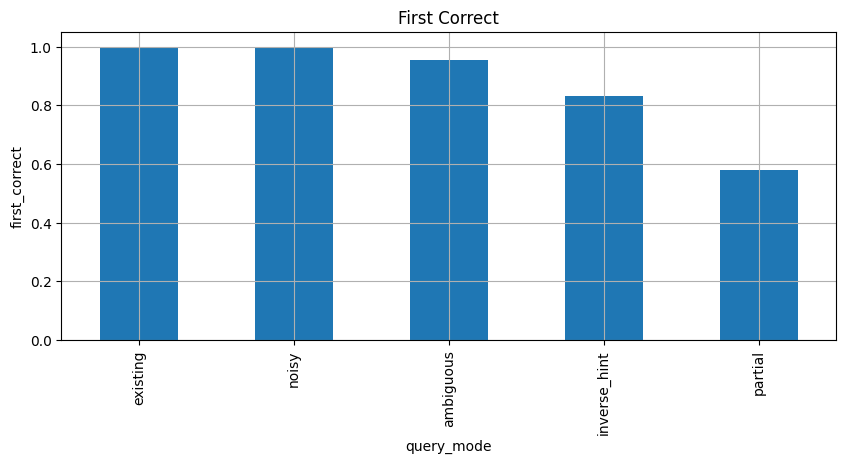

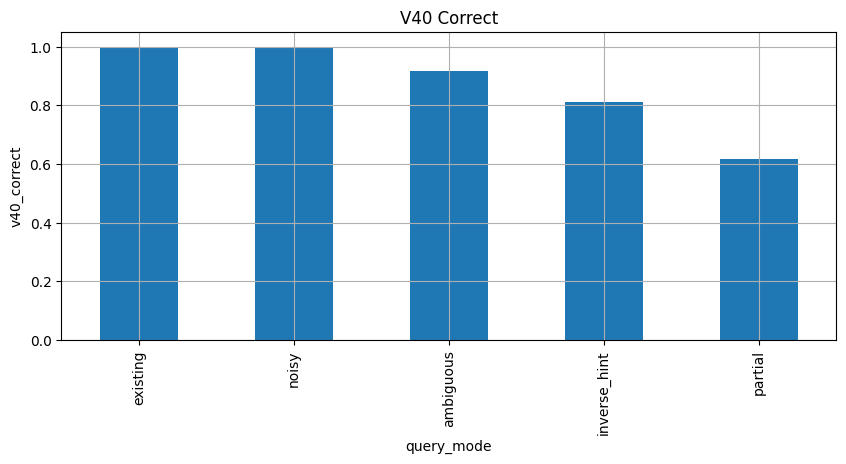

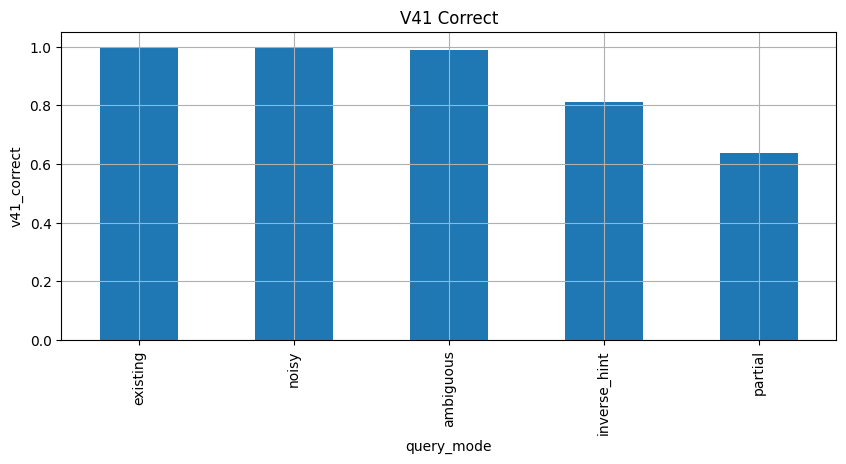

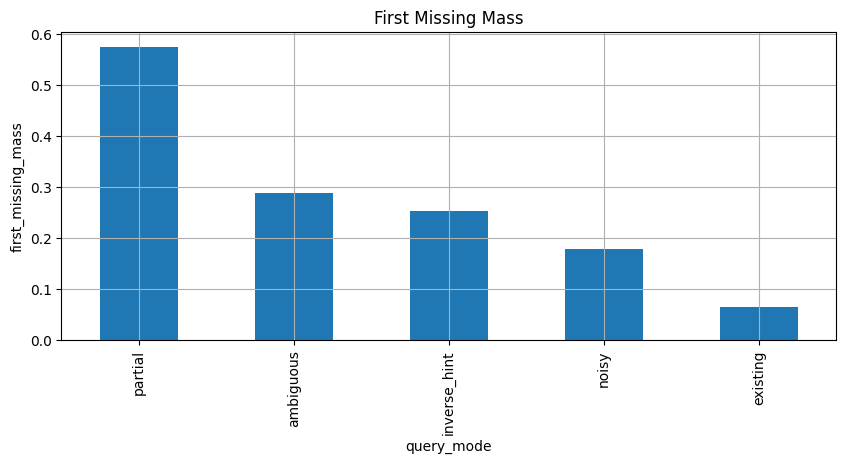

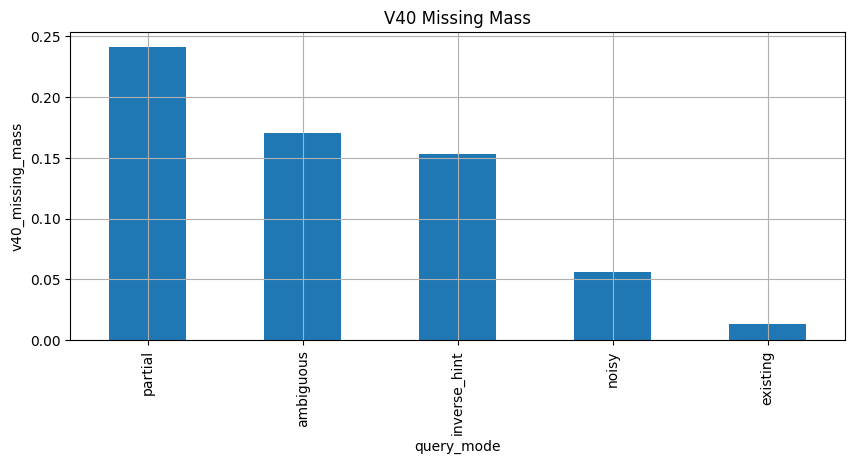

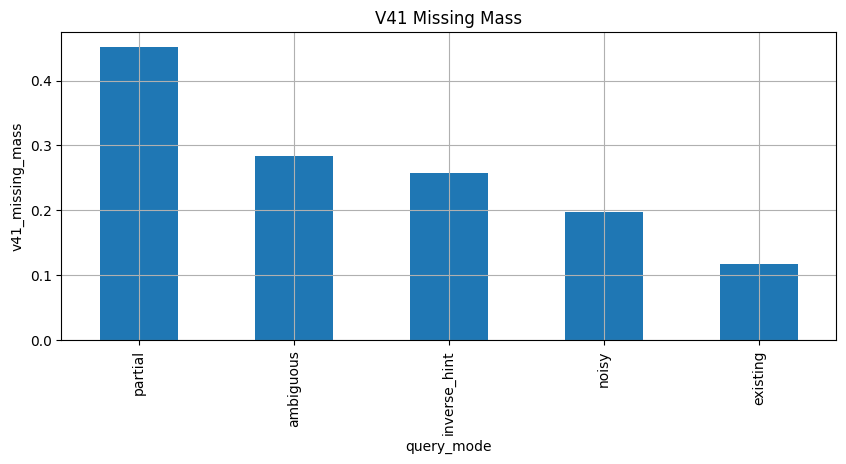

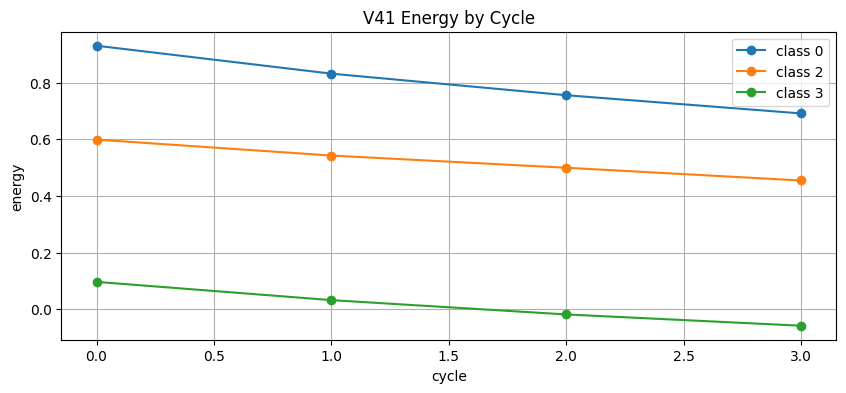

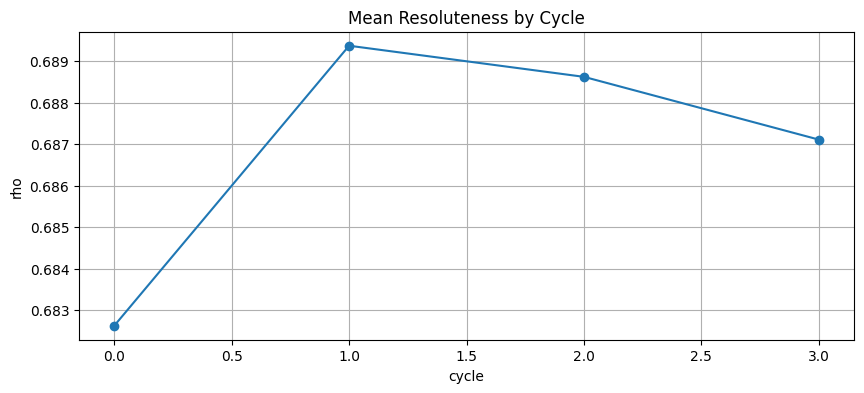

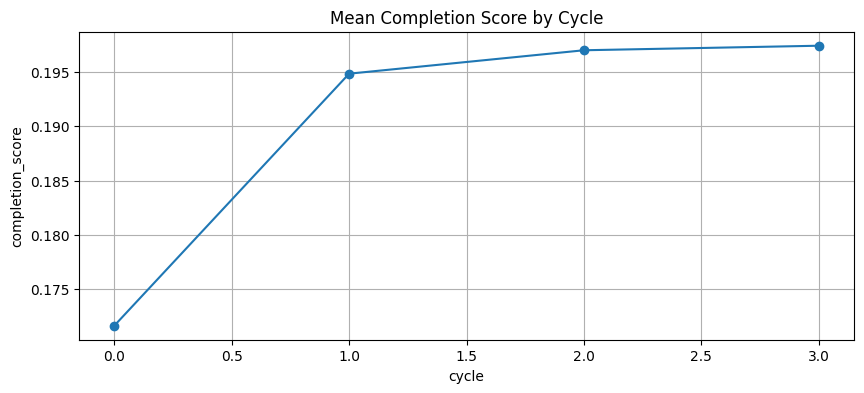

In [18]:

metrics = [
    "first_correct","v40_correct","v41_correct",
    "first_missing_mass","v40_missing_mass","v41_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()

if len(completion_trace_df):
    plt.figure(figsize=(10, 4))
    for cls in sorted(completion_trace_df["class"].unique()):
        df = completion_trace_df[completion_trace_df["class"] == cls]
        plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
    plt.title("V41 Energy by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(completion_trace_df.groupby("cycle")["rho"].mean(), marker="o")
    plt.title("Mean Resoluteness by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("rho")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(completion_trace_df.groupby("cycle")["completion_score"].mean(), marker="o")
    plt.title("Mean Completion Score by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("completion_score")
    plt.show()



## Practical readout

This notebook tests the bridge directly:

- **Interface** declares the cavity
- **Surface** supplies local fits
- **Completion** adds branch-specific support and rival-specific anti-flux
- one shared matter field updates under all three

Read first:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `completion_summary`
- `completion_trace_df`
